In [50]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mahmoudalimahmoud/students-data/Students - Students.csv


# Import Libraries

In [51]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Reading Dataset

In [52]:
data = pd.read_csv("/kaggle/input/datasets/mahmoudalimahmoud/students-data/Students - Students.csv")
df = data.copy()
df

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,20,Other,Undergraduate,3.93,1.42,0.54,2.58,2.62,9.30,...,113,496,0,0,Good,9,35.55,33.24,48.83,22.51
4996,4997,24,Male,High School,4.00,0.00,3.00,4.45,2.47,6.42,...,146,411,0,1,Poor,5,16.87,59.07,23.32,2.00
4997,4998,22,Male,Undergraduate,5.63,2.52,2.89,3.58,1.07,6.65,...,123,306,0,1,Good,7,23.85,47.72,41.09,27.89
4998,4999,17,Male,Undergraduate,3.58,2.83,1.53,5.88,1.28,7.36,...,54,304,1,1,Good,4,13.04,58.90,12.62,3.63


# Sample Of Data

In [53]:
print("Data Sample : \n")
df.sample()

Data Sample : 



,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
1474,1475,19,Female,High School,5.29,3.1,4.8,1.18,2.26,5.95,...,16,494,0,0,Average,4,33.0,33.8,47.33,43.03


# EDA (Exploratry Data Analysis)

# Data Information

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   academic_level        5000 non-null   object 
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   float64
 7   social_media_hours    5000 non-null   float64
 8   gaming_hours          5000 non-null   float64
 9   sleep_hours           5000 non-null   float64
 10  screen_time_hours     5000 non-null   float64
 11  exercise_minutes      5000 non-null   int64  
 12  caffeine_intake_mg    5000 non-null   int64  
 13  part_time_job         5000 non-null   int64  
 14  upcoming_deadline     5000 non-null   int64  
 15  internet_quality     

# Data Describtion

In [55]:
df.describe()

,student_id,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,20.520400,4.539594,2.478734,2.011984,2.998086,1.564514,7.016492,6.979588,74.535600,251.450400,0.498200,0.501400,5.507400,29.431616,45.615324,37.267716,18.803752
std,1443.520003,2.870406,1.821665,1.177990,0.983906,1.467949,1.110807,1.163692,2.486214,42.932293,143.842712,0.500047,0.500048,2.869145,9.962902,14.246591,16.849397,12.130840
min,1.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1250.750000,18.000000,3.250000,1.660000,1.320000,1.990000,0.670000,6.237500,5.280000,37.000000,129.000000,0.000000,0.000000,3.000000,22.567500,35.727500,25.290000,9.337500
50%,2500.500000,20.000000,4.530000,2.480000,2.010000,2.980000,1.490000,7.010000,6.950000,75.000000,252.000000,0.000000,1.000000,5.000000,29.430000,45.690000,36.860000,18.010000
75%,3750.250000,23.000000,5.760000,3.290000,2.690000,4.030000,2.340000,7.810000,8.710000,112.000000,376.000000,1.000000,1.000000,8.000000,36.242500,55.352500,49.142500,27.400000
max,5000.000000,25.000000,11.840000,7.410000,6.000000,8.280000,5.640000,10.000000,15.300000,149.000000,499.000000,1.000000,1.000000,10.000000,63.480000,97.580000,98.020000,64.090000


In [56]:
print("describtion for object data : \n")
df.describe(include = "O")

describtion for object data : 



,gender,academic_level,internet_quality
count,5000,5000,5000
unique,3,3,3
top,Male,Postgraduate,Good
freq,1719,1687,1722


# Data Shape

In [57]:
df.shape

(5000, 21)

In [58]:
print(f"number of rows in datast = {df.shape[0]}")
print(f"number of columns in datast = {df.shape[1]}")

number of rows in datast = 5000
number of columns in datast = 21


In [59]:
print("first 5 rows in dataset")
df.head(5)

first 5 rows in dataset


,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


# Data Cleaning & Preprocessing

In [60]:
print('Missing Values in Each Column: \n')
df.isna().sum()

Missing Values in Each Column: 



student_id              0
age                     0
gender                  0
academic_level          0
study_hours             0
self_study_hours        0
online_classes_hours    0
social_media_hours      0
gaming_hours            0
sleep_hours             0
screen_time_hours       0
exercise_minutes        0
caffeine_intake_mg      0
part_time_job           0
upcoming_deadline       0
internet_quality        0
mental_health_score     0
focus_index             0
burnout_level           0
productivity_score      0
exam_score              0
dtype: int64

In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
print("Records in academic_level")    

df["academic_level"].value_counts()

Records in academic_level


academic_level
Postgraduate     1687
High School      1672
Undergraduate    1641
Name: count, dtype: int64

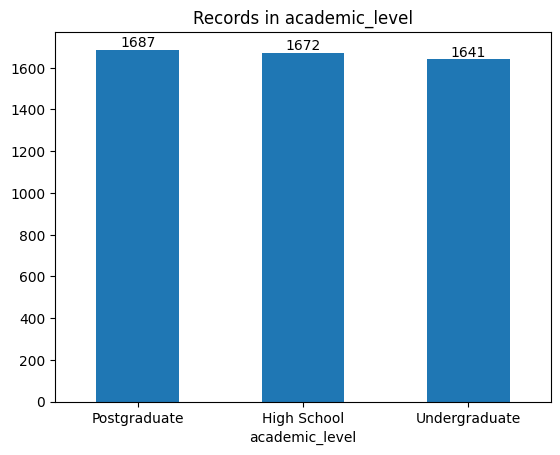

In [63]:
a = df["academic_level"].value_counts().plot(kind="bar")
for container in a.containers:
    a.bar_label(container)
plt.title("Records in academic_level")    
plt.xticks(rotation = 360)    
plt.show()

# Possible Analysis Questions   


# 1• How does sleep affect exam performance?  
1. weak positive correlation

In [64]:
sleep_hours_score = df[["sleep_hours","exam_score"]].corr()
sleep_hours_score

,sleep_hours,exam_score
sleep_hours,1.00000,0.23471
exam_score,0.23471,1.00000


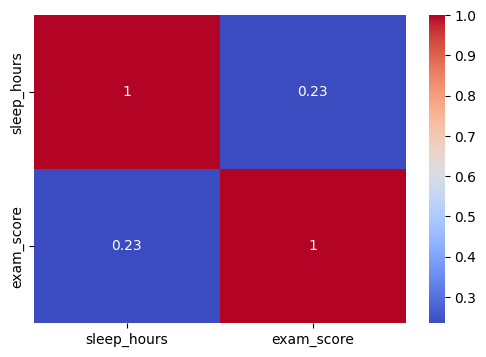

In [65]:
plt.figure(figsize=(6,4))
sns.heatmap(sleep_hours_score,annot=True,cmap="coolwarm")
plt.show()

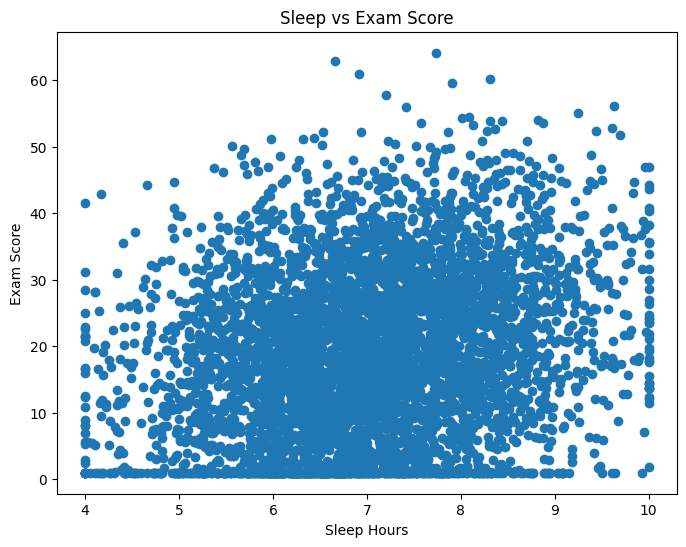

In [66]:
plt.figure(figsize=(8, 6))
plt.scatter(df["sleep_hours"], df["exam_score"])
plt.xlabel("Sleep Hours")
plt.ylabel("Exam Score")
plt.title("Sleep vs Exam Score")
plt.show()

# or

In [109]:
bins = [4,6.3,7.01,8,10]
labels = ["4-6.3 H","6.3-7 H","7-8 H","8-10 H"]
df["sleep_category"] = pd.cut(df["sleep_hours"],bins=bins,labels=labels)

In [122]:
df.groupby("sleep_category",observed=True)["exam_score"].mean()

sleep_category
4-6.3 H    15.575034
6.3-7 H    17.349290
7-8 H      20.074491
8-10 H     23.019302
Name: exam_score, dtype: float64

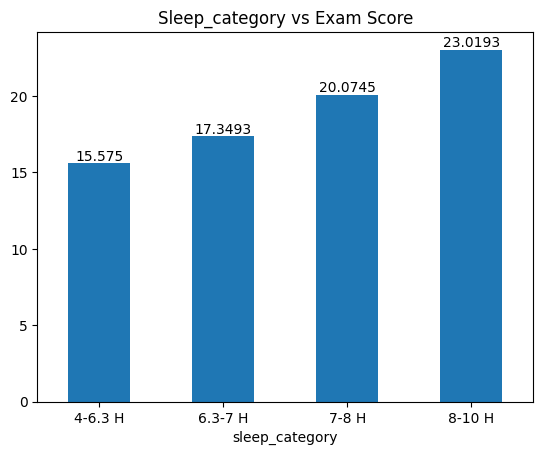

In [121]:
a = df.groupby("sleep_category",observed=True)["exam_score"].mean().plot(kind="bar")
plt.xticks(rotation = 360)
plt.title("Sleep_category vs Exam Score")
for container in a.containers:
    a.bar_label(container)
plt.show()    

# 2• Does social media usage reduce productivity?  
# No

In [68]:
social_media_score = df[["social_media_hours","productivity_score"]].corr()
social_media_score

,social_media_hours,productivity_score
social_media_hours,1.000000,-0.070052
productivity_score,-0.070052,1.000000


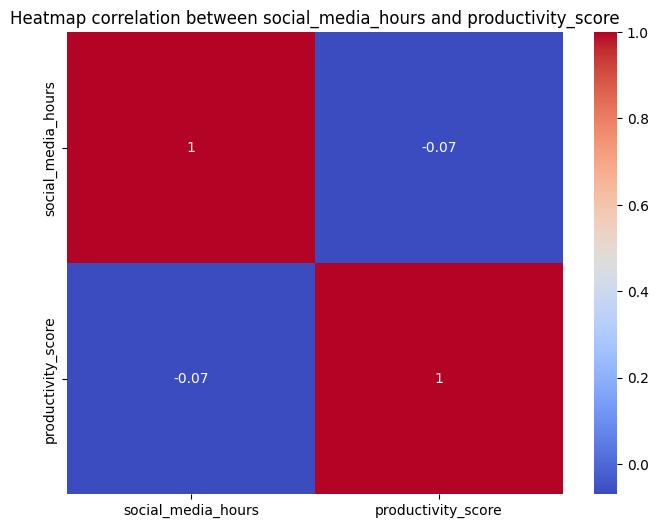

In [69]:
plt.figure(figsize=(8,6))
sns.heatmap(social_media_score,annot=True,cmap="coolwarm")
plt.title("Heatmap correlation between social_media_hours and productivity_score")
plt.show()

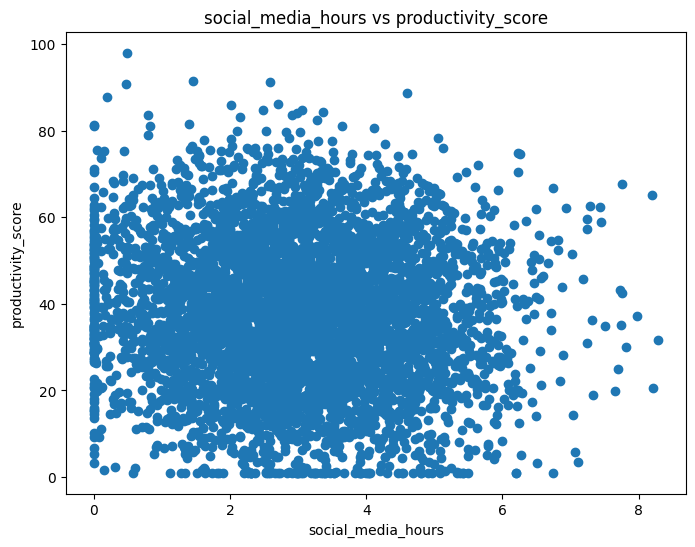

In [70]:
plt.figure(figsize=(8, 6))
plt.scatter(df["social_media_hours"], df["productivity_score"])
plt.xlabel("social_media_hours")
plt.ylabel("productivity_score")
plt.title("social_media_hours vs productivity_score")
plt.show()

# or

In [112]:
bins = [0,2,3,4.03,8.3]
labels = ["0-2 H","2-3 H","3-4 H","4-8.5 H"]
df["social_media_hours_category"] = pd.cut(df["social_media_hours"],bins=bins,labels=labels)

In [119]:
df.groupby("social_media_hours_category",observed=True)["productivity_score"].mean()

social_media_hours_category
0-2 H      38.882893
2-3 H      37.120268
3-4 H      36.965065
4-8.5 H    35.930911
Name: productivity_score, dtype: float64

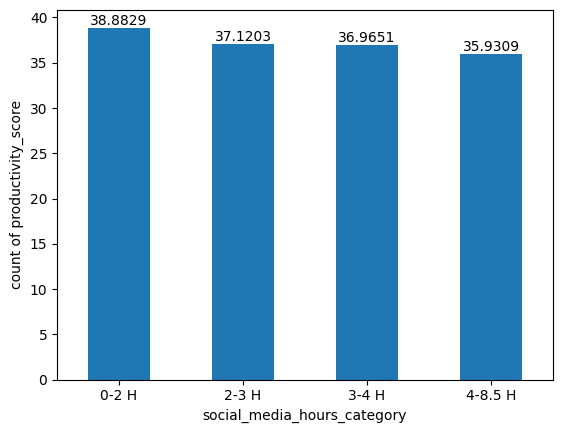

In [140]:
b = df.groupby("social_media_hours_category",observed=True)["productivity_score"].mean().plot(kind="bar")
plt.xticks(rotation = 360)
plt.title=("social_media_hours_category vs productivity_score")
plt.ylabel("count of productivity_score")
for container in b.containers:
    b.bar_label(container)
plt.show()    

# 3. • Relationship between burnout and mental health.  
# No correlation

In [72]:
burnout_health_score=df[["mental_health_score","burnout_level"]].corr()
burnout_health_score

,mental_health_score,burnout_level
mental_health_score,1.000000,0.008399
burnout_level,0.008399,1.000000


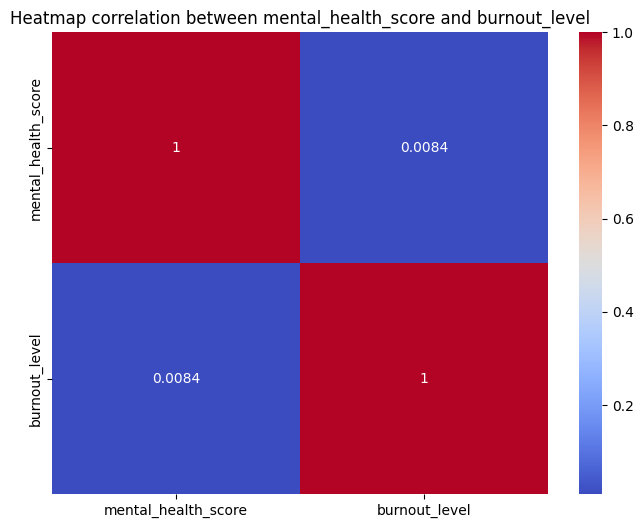

In [73]:
plt.figure(figsize=(8,6))
sns.heatmap(burnout_health_score,annot=True,cmap="coolwarm")
plt.title("Heatmap correlation between mental_health_score and burnout_level")
plt.show()

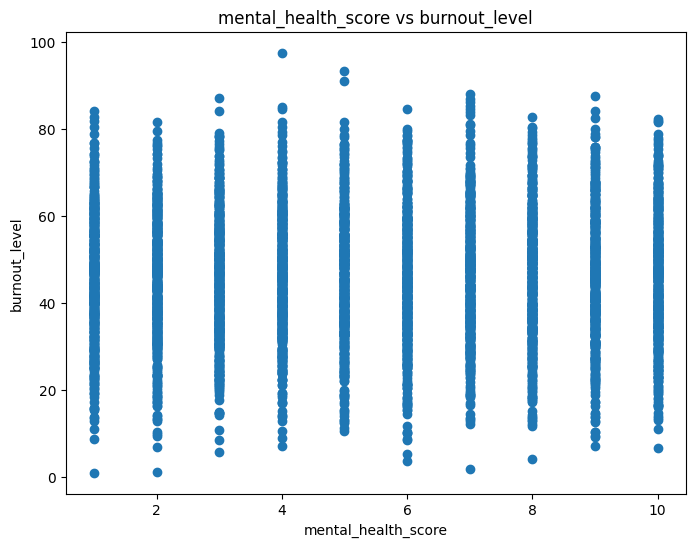

In [123]:
plt.figure(figsize=(8, 6))
plt.scatter(df["mental_health_score"], df["burnout_level"])
plt.xlabel("mental_health_score")
plt.ylabel("burnout_level")
plt.title("mental_health_score vs burnout_level")
plt.show()

# 4• Does caffeine improve focus?  
# NO

In [127]:
caffine_focus = df[["caffeine_intake_mg","focus_index"]].corr()
caffine_focus

,caffeine_intake_mg,focus_index
caffeine_intake_mg,1.000000,-0.003389
focus_index,-0.003389,1.000000


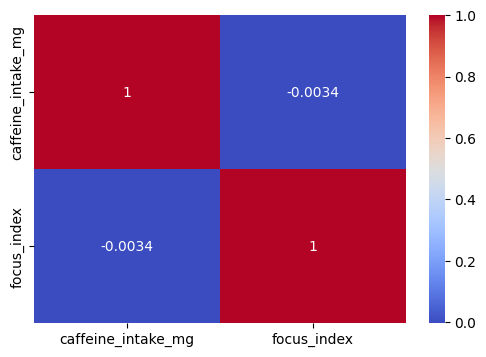

In [141]:
plt.figure(figsize=(6,4))
sns.heatmap(caffine_focus,annot=True,cmap="coolwarm")
plt.title=("heatmap correlation caffeine_intake_mg vs focus_index")
plt.show()

# or

In [130]:
bins = [0,130,252,376,500]
labels = ["0-130 mg","130-252 mg","252-376 mg","376-500 mg"]
df["caffeine_intake_mg_category"] = pd.cut(df["caffeine_intake_mg"],bins=bins,labels=labels)

In [131]:
df.groupby("caffeine_intake_mg_category",observed=True)["focus_index"].mean()

caffeine_intake_mg_category
0-130 mg      29.609566
130-252 mg    29.384826
252-376 mg    29.348582
376-500 mg    29.403896
Name: focus_index, dtype: float64

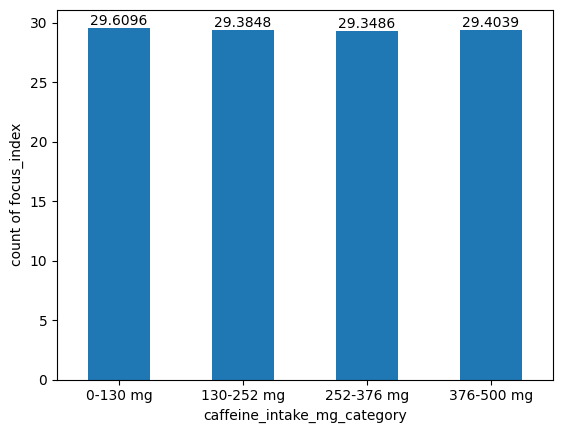

In [138]:
c = df.groupby("caffeine_intake_mg_category",observed=True)["focus_index"].mean().plot(kind="bar")
plt.xticks(rotation = 360)
plt.title=("caffeine_intake_mg_category vs focus_index")
plt.ylabel("count of focus_index")
for container in c.containers:
    c.bar_label(container)
plt.show()    

# 5• Impact of part-time jobs on academic performance.  


In [86]:
part_time_score = df.groupby('part_time_job')['exam_score'].mean().reset_index()
part_time_score

,part_time_job,exam_score
0,0,20.614328
1,1,16.980092


In [89]:
fig_part_time_score = px.bar(part_time_score,x="part_time_job",y="exam_score",text_auto=True,title="Average of exam_score for part_time_job")
fig_part_time_score.show()

# 6• Effect of study hours on exam scores. 

In [82]:
study_hours_score = df[["exam_score","study_hours"]].corr()
study_hours_score

,exam_score,study_hours
exam_score,1.000000,0.513434
study_hours,0.513434,1.000000


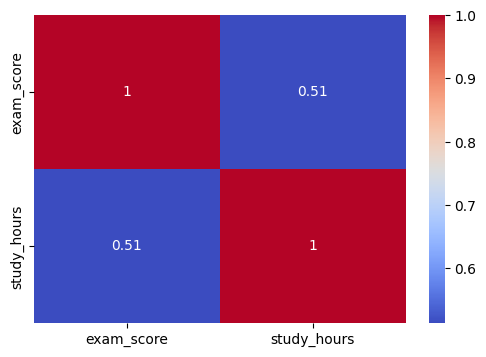

In [84]:
plt.figure(figsize=(6,4))
sns.heatmap(study_hours_score,annot=True,cmap="coolwarm")
plt.show()

# or

In [144]:
bins = [0,3.25,4.53,5.76,11.84]
labels = ["0-3.25 H","3.25-4.53 H","4.53-5.76 H","5.76-12 H"]
df["study_hours_category"] = pd.cut(df["study_hours"],bins=bins,labels=labels)

In [145]:
df.groupby("study_hours_category", observed=True)["exam_score"].mean()

study_hours_category
0-3.25 H       11.326705
3.25-4.53 H    16.581809
4.53-5.76 H    20.587712
5.76-12 H      26.894147
Name: exam_score, dtype: float64

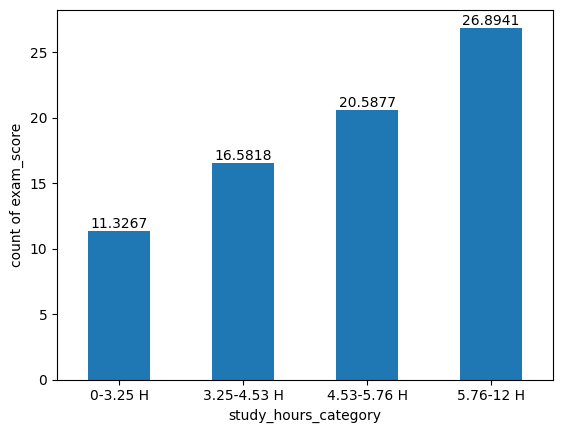

In [148]:
xyz = df.groupby("study_hours_category", observed=True)["exam_score"].mean().plot(kind="bar")
plt.xticks(rotation = 360)
plt.title=("study_hours_category vs exam_score")
plt.ylabel("count of exam_score")
for container in xyz.containers:
    xyz.bar_label(container)
plt.show()    